# StyleCLIP

Редактирование изображений -- очень важная и интересная задача в мире генеративных моделей. В этом ноутбуке мы с вами попробуем решить эту задачу на основе работы [StyleCLIP](https://arxiv.org/abs/2103.17249).

Данный метод позволяет редактировать изображения, сгенерированные [StyleGAN2](https://github.com/rosinality/stylegan2-pytorch), используя текстовые описания. Например, вы можете взять фотографию человека и с помощью текстовой подсказки "сделать волосы кудрявыми" изменить прическу на фотографии. Основная идея данной работы в том, чтобы "подвинуть" изначальный латент так, чтобы сгенерированное из него изображение лучше соответствовало предложенному промпту. Авторы предлагают два основных подхода:

- Оптимизация латентного вектора на основе CLIP Loss

- Обучение специального Mapper для сдвига

Более подробно про эти два подхода можно почитать в самой стате [StyleCLIP](https://arxiv.org/abs/2103.17249).

Мы с вами рассмотрим только одну часть предложенного метода, а именно оптимизацию для редактирования. Как уже было сказано, StyleCLIP оптимизирует латентный вектор [StyleGAN2](https://arxiv.org/abs/1912.04958) для более точного соотвествия заданному промпту.

Идея StyleCLIP с оптимизацией отображена на изображении ниже.




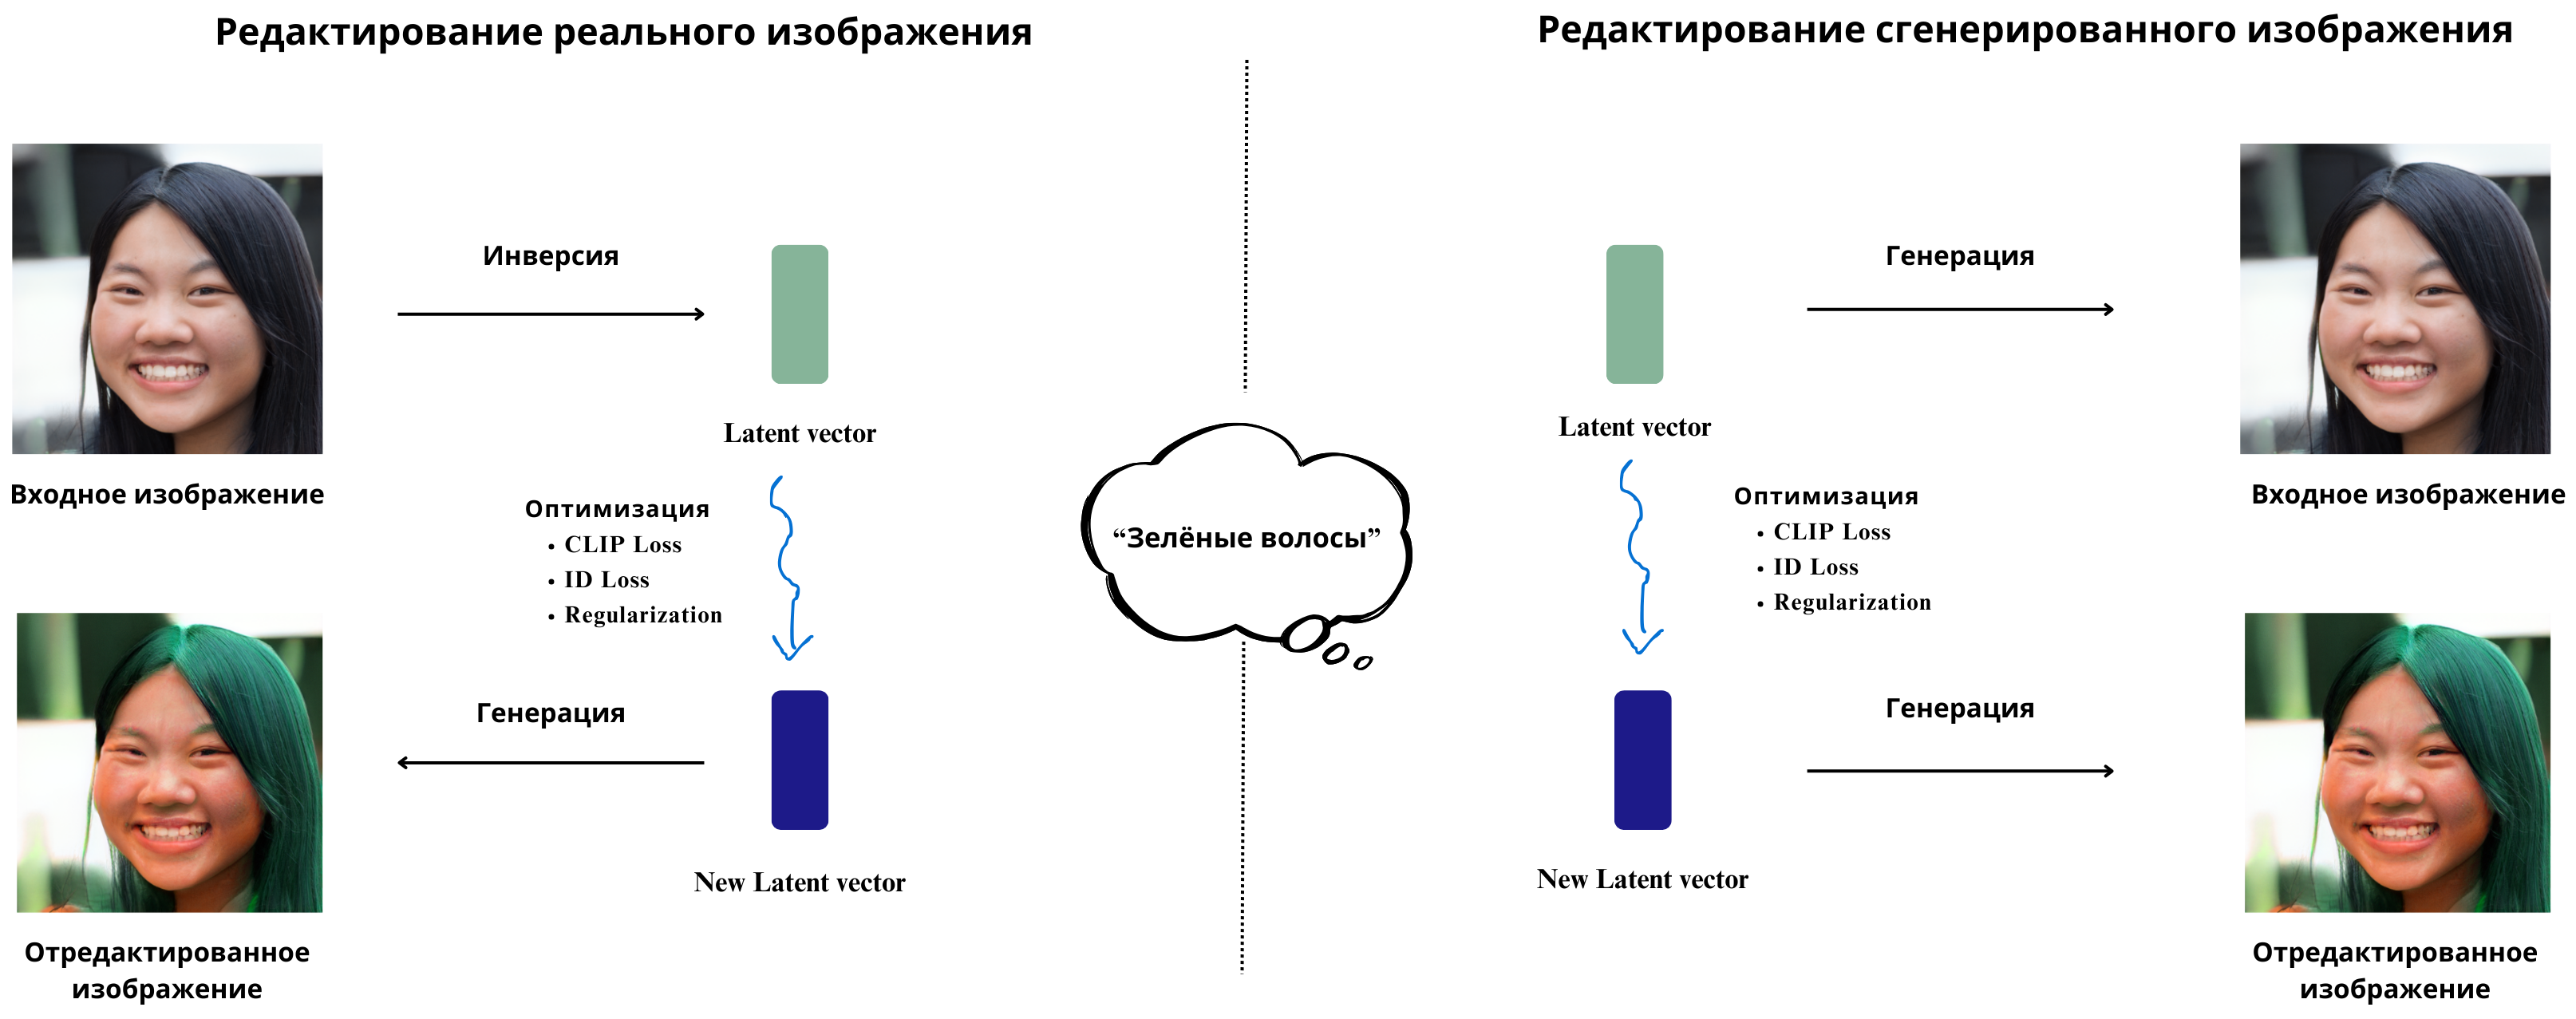

Наш план будет состоять в следующем:

1. Подготовка всех моделей для оптимизации

2. Реализация всех необходимых функций потерь:

  - CLIP Loss (1 балла)
  - ID Loss (1 балла)

3. Подготовка кода оптимизации (2 балла)

4. Выводы из полученных результатов (1 балл)

Давайте же попробуем написать код для этой оптимизации!

## Установка необходимых библиотек и подготовка окружения
Начнем с установки необходимых библиотек и клонирования репозитория StyleCLIP, чтобы использовать его методы.

In [2]:
# Установка необходимых библиотек

# Установка зависимостей
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
# Установка дополнительных библиотек
!pip install Ninja

# Импорт нужных библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-n0uj6zw2
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-n0uj6zw2
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=0e617de99488fe07bb7f68c515ae15d3f91cd1229a1b07a2a5d01e8e23d7df81
  Stored in directory: /tmp/pip-ephem-wheel-cache-qoim1obm/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.3 MB/s eta 0:00:00


In [3]:
# Клонирование репозитория StyleGAN2
!git clone https://github.com/rosinality/stylegan2-pytorch.git

Cloning into 'stylegan2-pytorch'...
remote: Enumerating objects: 395, done.
remote: Total 395 (delta 0), reused 0 (delta 0), pack-reused 395 (from 1)
Receiving objects: 100% (395/395), 122.51 MiB | 17.76 MiB/s, done.
Resolving deltas: 100% (205/205), done.


In [4]:
cd stylegan2-pytorch/

/content/stylegan2-pytorch


In [5]:
# Будем работать с конкретным сидом
torch.manual_seed(345)

## Основная идея статьи


Как уже было сказано, мы хотим редактировать изображение с помощью текста. Для этого будем использовать [CLIP](https://paperswithcode.com/method/clip) модель для некоторого гайданса в процессе оптимизации.

Задачу мы хотим построить следующим образом: имея исходный латентный вектор $w \in W$ мы хотим оптимизировать его под текстовый запрос $t$. Давайте подгрузм нашу модель и сгенерируем картинку для дальнейшей оптимизации.

Для работы со StyleGAN-2 нам для начала нужно скачать модель. Для скачивания мы используем следующий код:

In [6]:
!pip install pydrive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 52.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydrive: filename=PyDrive-1.3.1-py3-none-any.whl size=27433 sha256=eb9ae6f067fd7286914abebb21ff6453ba91a91d1f4a215846c6033ac63fec58
  Stored in directory: /root/.cache/pip/wheels/6c/10/da/a5b513f5b3916fc391c20ee7b4633e5cf3396d570cdd74970f
Successfully built pydrive


In [7]:
!pip install gdown

In [8]:
import requests
import re

def download_google_drive_file(file_id, destination):
    URL = "https://drive.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params={'id': file_id}, stream=True)
    token = None
    # Ищем confirm-токен для больших файлов
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            token = value
            break
    if token:
        params = {'id': file_id, 'confirm': token}
        response = session.get(URL, params=params, stream=True)
    # Сохраняем файл
    with open(destination, 'wb') as f:
        for chunk in response.iter_content(32768):
            if chunk:
                f.write(chunk)
    print(f'Скачан: {destination}')

ids = {
    '1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT': 'stylegan2-ffhq-config-f.pt',
    '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL': 'model_ir_se50.pth'
}

for file_id, filename in ids.items():
    download_google_drive_file(file_id, filename)

Скачан: stylegan2-ffhq-config-f.pt
Скачан: model_ir_se50.pth


In [10]:
import sys
sys.path.append('/content/stylegan2-pytorch')

In [14]:
!pip install stylegan2-pytorch -q
from stylegan2_pytorch import StyleGAN2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 64.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.4 MB/s eta 0:00:00


In [18]:
import os
import sys
import torch
import gdown

broken_file = '/content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt'
if os.path.exists(broken_file):
    os.remove(broken_file)

print("Скачивание весов StyleGAN2...")
file_id = '1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT'
gdown.download(f'https://drive.google.com/uc?id={file_id}', broken_file, quiet=False)

sys.path.append('/content/stylegan2-pytorch')
from model import Generator

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 3456
torch.manual_seed(seed)

latent_dim = 512
generator = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)

state_dict = torch.load(broken_file, map_location=device, weights_only=False)
generator.load_state_dict(state_dict['g_ema'])
generator.eval()

print("Генератор StyleGAN2 загружен.")

Скачивание весов StyleGAN2...


Downloading...
From (original): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT
From (redirected): https://drive.google.com/uc?id=1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT&confirm=t&uuid=88733056-8a99-4b12-b117-ecb3b75b8a1a
To: /content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt
100%|██████████| 381M/381M [00:11<00:00, 33.5MB/s]


Генератор StyleGAN2 загружен.


### Функция для генерации изображения из латентного вектора
Эта функция генерирует изображение из латентного вектора $z \in Z$ ($w \in W$), что нам пригодится для визуализации процесса редактирования.

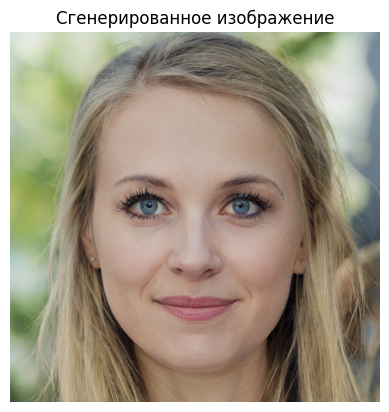

Размер изображения: torch.Size([1, 3, 1024, 1024])


In [24]:
# Генерация изображения из случайного Z-вектора
latent_z = torch.randn(1, 512, device=device)

# Получаем средний латент для truncation (можно None, но тогда truncation должен быть 1)
with torch.no_grad():
    mean_latent = generator.mean_latent(10000)  # средний латент из 10000 примеров

with torch.no_grad():
    result = generator([latent_z], input_is_latent=False, truncation=0.7, truncation_latent=mean_latent)
    target_img = result[0]  # Берём только изображение

# Визуализация
img = (target_img.permute(0, 2, 3, 1) * 0.5 + 0.5).clamp(0, 1)
plt.imshow(img[0].cpu())
plt.axis('off')
plt.title("Сгенерированное изображение")
plt.show()

print(f"Размер изображения: {target_img.shape}")

## Задача оптимизации

Теперь давайте подронее сформулируем задачу оптимизации.

Нам необходимо следующее:

- Отредактированное изображение соответствует текстовому запросу

- Сохраняет identity изначального человека.

Авторы предлагают следующий лосс для оптимизации:

$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$

Давайте разберёмся с каждой частью подробнее.

### CLIP loss

Начнём мы с CLIP loss.

 $D_{\text{CLIP}}$ — косинусное расстояние между эмбеддингами [CLIP](https://habr.com/ru/articles/539312/) для двух аргументов.

$$D_{\text{CLIP}}(G(w), t) = 1 - \frac{\langle E_{\text{CLIP}}(G(w)) \cdot E_{\text{CLIP}}(t) \rangle }{\|E_{\text{CLIP}}(G(w))\| \cdot \|E_{\text{CLIP}}(t)\|}$$


In [47]:
import torch
import clip
import torch.nn.functional as F

class CLIPLoss(torch.nn.Module):
    """
    Класс CLIP Loss с передачей градиентов через изображение
    """

    def __init__(self, stylegan_size=1024, device='cuda'):
        super(CLIPLoss, self).__init__()
        # Загружаем предварительно обученную модель CLIP
        self.model, self.preprocess = clip.load("ViT-B/32", device=device)
        self.model.eval()

        # Замораживаем веса CLIP (они не обучаются, но градиенты проходят через image)
        for param in self.model.parameters():
            param.requires_grad = False

        self.upsample = torch.nn.Upsample(scale_factor=7, mode='bilinear', align_corners=False)
        self.avg_pool = torch.nn.AvgPool2d(kernel_size=stylegan_size // 32)
        self.device = device

    def forward(self, image, text):
        """
        Вычисляет CLIP loss между изображением и текстом.
        Градиенты проходят через image.
        """
        # Преобразуем изображение для CLIP
        image = self.avg_pool(self.upsample(image))  # [1, 3, 224, 224]
        image = (image + 1) / 2  # из [-1,1] в [0,1]
        image = image.clamp(0, 1)

        # Токенизируем текст
        text_tokens = clip.tokenize([text] if isinstance(text, str) else text).to(self.device)

        # ❌ УБРАТЬ with torch.no_grad(): ❌
        # Получаем эмбеддинги (градиенты идут через image)
        image_features = self.model.encode_image(image)
        text_features = self.model.encode_text(text_tokens)

        # Нормализуем эмбеддинги
        image_features = F.normalize(image_features, dim=-1)
        text_features = F.normalize(text_features, dim=-1)

        # Косинусное сходство
        cosine_sim = (image_features * text_features).sum(dim=-1)

        # CLIP loss = 1 - cosine_similarity
        loss = 1 - cosine_sim

        return loss.mean()

# Использование
clip_loss_fn = CLIPLoss(device=device)

In [48]:
clip_loss = CLIPLoss()

### ID loss

Для сохранения identity человека использует специально предобученную модель [ArcFace](https://arxiv.org/abs/1801.07698), которая по фотографии вычисляет некоторые характерные для человека embedding вектора. Затем нам необходимо посчитать косинусное расстояние между ожидаемым embedding вектором и тем, что получается в процессе оптимизации:

$$ L_{\text{ID}}(w) = 1 - \langle R(G(w_s)), R(G(w)) \rangle $$

Обратите внимание, что здесь не используется дополнительная нормировка


Давайте подгрузим нашу модель и реализуем желаемую функцию потерь.


### Подгрузка модели

Далее у нас будет подгрузка самой модели, позаимствованная из репозитория [StyleCLIP](https://github.com/orpatashnik/StyleCLIP/blob/main/models/facial_recognition/helpers.py). Вы можете более подробно ознакомиться с кодом этой модели ниже, но мы не будем заострять на ней внимание.


In [49]:
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Dropout, Sequential, Module

"""
Modified Backbone implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""
from collections import namedtuple
import torch
from torch.nn import Conv2d, BatchNorm2d, PReLU, ReLU, Sigmoid, MaxPool2d, AdaptiveAvgPool2d, Sequential, Module

"""
ArcFace implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""


class Flatten(Module):
	def forward(self, input):
		return input.view(input.size(0), -1)


def l2_norm(input, axis=1):
	norm = torch.norm(input, 2, axis, True)
	output = torch.div(input, norm)
	return output


class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])):
	""" A named tuple describing a ResNet block. """


def get_block(in_channel, depth, num_units, stride=2):
	return [Bottleneck(in_channel, depth, stride)] + [Bottleneck(depth, depth, 1) for i in range(num_units - 1)]


def get_blocks(num_layers):
	if num_layers == 50:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=4),
			get_block(in_channel=128, depth=256, num_units=14),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 100:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=13),
			get_block(in_channel=128, depth=256, num_units=30),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 152:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=8),
			get_block(in_channel=128, depth=256, num_units=36),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	else:
		raise ValueError("Invalid number of layers: {}. Must be one of [50, 100, 152]".format(num_layers))
	return blocks


class SEModule(Module):
	def __init__(self, channels, reduction):
		super(SEModule, self).__init__()
		self.avg_pool = AdaptiveAvgPool2d(1)
		self.fc1 = Conv2d(channels, channels // reduction, kernel_size=1, padding=0, bias=False)
		self.relu = ReLU(inplace=True)
		self.fc2 = Conv2d(channels // reduction, channels, kernel_size=1, padding=0, bias=False)
		self.sigmoid = Sigmoid()

	def forward(self, x):
		module_input = x
		x = self.avg_pool(x)
		x = self.fc1(x)
		x = self.relu(x)
		x = self.fc2(x)
		x = self.sigmoid(x)
		return module_input * x


class bottleneck_IR(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False), PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False), BatchNorm2d(depth)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class bottleneck_IR_SE(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR_SE, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False),
			PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False),
			BatchNorm2d(depth),
			SEModule(depth, 16)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class Backbone(Module):
	def __init__(self, input_size, num_layers, mode='ir', drop_ratio=0.4, affine=True):
		super(Backbone, self).__init__()
		assert input_size in [112, 224], "input_size should be 112 or 224"
		assert num_layers in [50, 100, 152], "num_layers should be 50, 100 or 152"
		assert mode in ['ir', 'ir_se'], "mode should be ir or ir_se"
		blocks = get_blocks(num_layers)
		if mode == 'ir':
			unit_module = bottleneck_IR
		elif mode == 'ir_se':
			unit_module = bottleneck_IR_SE
		self.input_layer = Sequential(Conv2d(3, 64, (3, 3), 1, 1, bias=False),
									  BatchNorm2d(64),
									  PReLU(64))
		if input_size == 112:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 7 * 7, 512),
			                               BatchNorm1d(512, affine=affine))
		else:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 14 * 14, 512),
			                               BatchNorm1d(512, affine=affine))

		modules = []
		for block in blocks:
			for bottleneck in block:
				modules.append(unit_module(bottleneck.in_channel,
										   bottleneck.depth,
										   bottleneck.stride))
		self.body = Sequential(*modules)

	def forward(self, x):
		x = self.input_layer(x)
		x = self.body(x)
		x = self.output_layer(x)
		return l2_norm(x)


def IR_50(input_size):
	"""Constructs a ir-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_101(input_size):
	"""Constructs a ir-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_152(input_size):
	"""Constructs a ir-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_SE_50(input_size):
	"""Constructs a ir_se-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_101(input_size):
	"""Constructs a ir_se-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_152(input_size):
	"""Constructs a ir_se-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir_se', drop_ratio=0.4, affine=False)
	return model

### ID loss

Теперь непосредственно реализуем нашу функцию потерь.

In [50]:
class IDLoss(nn.Module):
    def __init__(self, model_weights, device='cuda'):
        super(IDLoss, self).__init__()
        print('Loading ResNet ArcFace')

        # Создаём модель
        self.facenet = IR_SE_50(input_size=112)

        # Загружаем веса с игнорированием несовпадений
        state_dict = torch.load(model_weights, map_location=device, weights_only=False)

        # Убираем лишние ключи, если они есть
        new_state_dict = {}
        for k, v in state_dict.items():
            # Убираем префикс 'module.' если есть
            if k.startswith('module.'):
                k = k[7:]
            new_state_dict[k] = v

        # Загружаем с strict=False, чтобы игнорировать несовпадающие ключи
        self.facenet.load_state_dict(new_state_dict, strict=False)

        self.pool = torch.nn.AdaptiveAvgPool2d((256, 256))
        self.face_pool = torch.nn.AdaptiveAvgPool2d((112, 112))
        self.facenet.eval()
        self.facenet.to(device)

        # Замораживаем веса
        for param in self.facenet.parameters():
            param.requires_grad = False

        print("✅ ID Loss model loaded successfully")

    def extract_feats(self, x):
        if x.shape[2] != 256:
            x = self.pool(x)
        x = x[:, :, 35:223, 32:220]
        x = self.face_pool(x)
        x_feats = self.facenet(x)
        return x_feats

    def forward(self, y_hat, y):
        n_samples = y.shape[0]
        y_feats = self.extract_feats(y)
        y_hat_feats = self.extract_feats(y_hat)

        y_feats = y_feats.detach()

        loss = 0
        for i in range(n_samples):
            cosine_sim = torch.cosine_similarity(y_feats[i], y_hat_feats[i], dim=0)
            loss += (1 - cosine_sim)

        return loss / n_samples

In [51]:
model_path = "/content/stylegan2-pytorch/model_ir_se50.pth"
id_loss = IDLoss(model_path, device)
print("✅ ID Loss модель загружена успешно")

# Проверка на случайном тензоре
test_img = torch.randn(1, 3, 1024, 1024).to(device)
test_feats = id_loss.extract_feats(test_img)
print(f"Размер эмбеддинга: {test_feats.shape}")  # Ожидается [1, 512]

Loading ResNet ArcFace
✅ ID Loss model loaded successfully
✅ ID Loss модель загружена успешно
Размер эмбеддинга: torch.Size([1, 512])


## Инициализация латентного вектора и текстовой подсказки
Определим латентный вектор
𝑊
W для исходного изображения и преобразуем текстовую подсказку в вектор с помощью CLIP, что будет служить нашей целью для редактирования.

## Оптимизация для редактирования изображения
Реализуем оптимизацию, используя Adam. На каждом шаге обновляется латентный вектор $w \in W$ для минимизации потерь CLIP, пока результат не будет похож на текстовую подсказку.

Основной псевдокод оптимизации представлен ниже:

```python

for step in range(num_steps):  # <----------- итерируемся по датасету несколько раз
    torch.cuda.empty_cache() # <------------- очищаем кэш модели
    optimizer.zero_grad()  # <------------- обуляем градиенты модели
    image, _ = generator([latent], input_is_latent=True, randomize_noise=False)  # <------------- получаем картинку из StyleGAN-2
    loss = clip_loss + l2_lambda * l2_loss + id_lambda * id_loss
    loss.backward()  # <------------------- считаем градиенты
    optimizer.step()  # <------------------ делаем шаг градиентного спуска
    if convergence:  # <------------------- в случае сходимости выходим из цикла
        break
```

Где полная функция потерь считается по формуле:
$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$

Дополнительно сохраните значения лосс функций для дальнейшей визуализации.


In [52]:
# Подготавливаем текстовый промпт для оптимизации, который будет направлять изменение изображения.
prompt = "a person with green hair"

# Токенизируем промпт с помощью CLIP tokenizer и перемещаем на устройство (CPU или GPU).
# clip.tokenize: функция из библиотеки CLIP для токенизации текста.
text_inputs = torch.cat([clip.tokenize(prompt)]).to(device)

In [53]:
# Подготовим папку для сохранения результатов
import os
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

Работать предлагаем в пространстве $W$, давайте преобразуем наш вектор в styleSpace

In [54]:
# Получаем w-вектор из z-вектора с помощью mapping network генератора.
with torch.no_grad():
  latent_w = generator.style(latent_z_generated)

latent = latent_w.detach().clone()
latent.requires_grad = True

In [55]:
%matplotlib inline

Step [0/200], Total Loss: 0.7749, CLIP: 0.7749, ID: 0.0000, L2: 0.0000


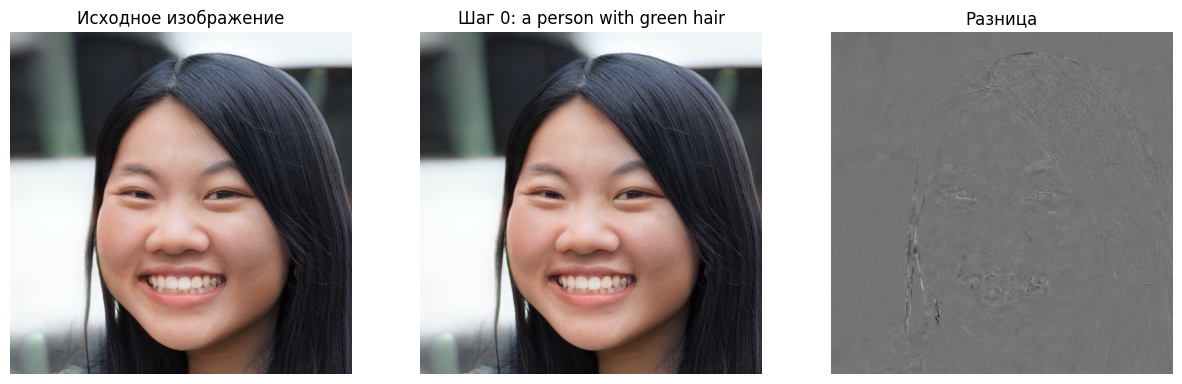

Step [50/200], Total Loss: 0.6139, CLIP: 0.6118, ID: 0.5151, L2: 0.2000


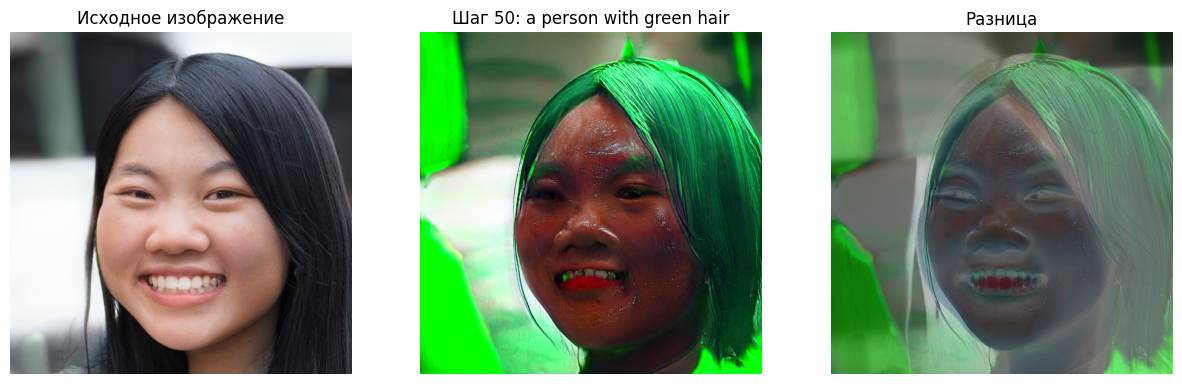

Step [100/200], Total Loss: 0.5822, CLIP: 0.5796, ID: 0.5113, L2: 0.2601


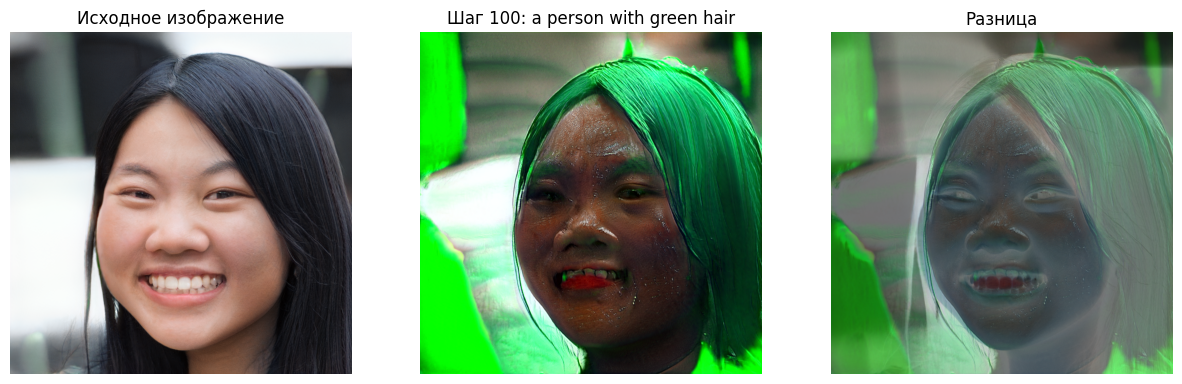

Step [150/200], Total Loss: 0.5741, CLIP: 0.5713, ID: 0.5113, L2: 0.2901


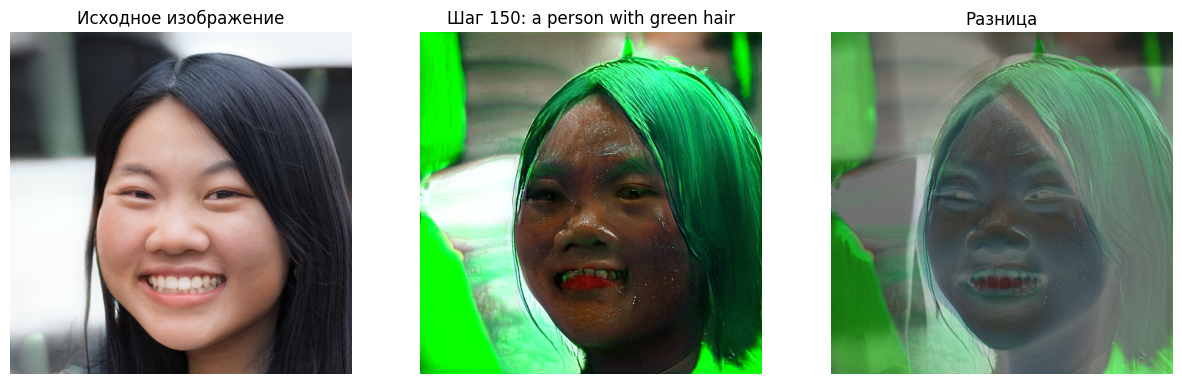

✅ Оптимизация завершена!


In [56]:
# Оптимизация для редактирования с помощью CLIP

# Создадим оптимизатор Adam
optimizer = torch.optim.Adam([latent], lr=0.08)
# А также выберем скедулер
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

num_steps = 200
l2_lambda = 0.008
id_lambda = 0.001

# Сохраняем лоссы
losses = {'id': [], 'l2': [], 'clip': [], 'all': []}

# Сохраняем начальное изображение для сравнения
with torch.no_grad():
    initial_img, _ = generator([latent], input_is_latent=True, randomize_noise=False)
    initial_img = initial_img.detach()

# Цикл оптимизации
for step in range(num_steps):
    torch.cuda.empty_cache()
    optimizer.zero_grad()

    # Генерируем изображение из текущего латента
    img_gen, _ = generator([latent], input_is_latent=True, randomize_noise=False)

    # Вычисляем CLIP loss
    clip_loss_val = clip_loss(img_gen, prompt)  # используем ваш CLIPLoss класс

    # Вычисляем L2 loss (регуляризация к исходному w)
    l2_loss_val = torch.mean((latent - latent_w.detach()) ** 2)

    # Вычисляем ID loss (сохранение идентичности)
    id_loss_val = id_loss(img_gen, initial_img)

    # Общий лосс
    total_loss = clip_loss_val + l2_lambda * l2_loss_val + id_lambda * id_loss_val

    # Сохраняем значения
    losses['clip'].append(clip_loss_val.item())
    losses['l2'].append(l2_loss_val.item())
    losses['id'].append(id_loss_val.item())
    losses['all'].append(total_loss.item())

    # Обратное распространение
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Визуализация
    if step % 50 == 0:
        print(f"Step [{step}/{num_steps}], Total Loss: {total_loss.item():.4f}, CLIP: {clip_loss_val.item():.4f}, ID: {id_loss_val.item():.4f}, L2: {l2_loss_val.item():.4f}")

        # Визуализация изображений
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))

        # Исходное изображение
        axs[0].imshow((initial_img.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2)
        axs[0].set_title("Исходное изображение")
        axs[0].axis('off')

        # Текущее сгенерированное изображение
        axs[1].imshow((img_gen.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2)
        axs[1].set_title(f"Шаг {step}: {prompt}")
        axs[1].axis('off')

        # Разница
        diff = (img_gen - initial_img).cpu().detach()[0].permute(1, 2, 0)
        diff = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)
        axs[2].imshow(diff)
        axs[2].set_title("Разница")
        axs[2].axis('off')

        plt.show()

        # Сохраняем изображение
        save_img = (img_gen.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2
        plt.imsave(f"{save_dir}/step_{step}.png", save_img.numpy())

print("✅ Оптимизация завершена!")

Визуализируйте лоссы в зависимости от step

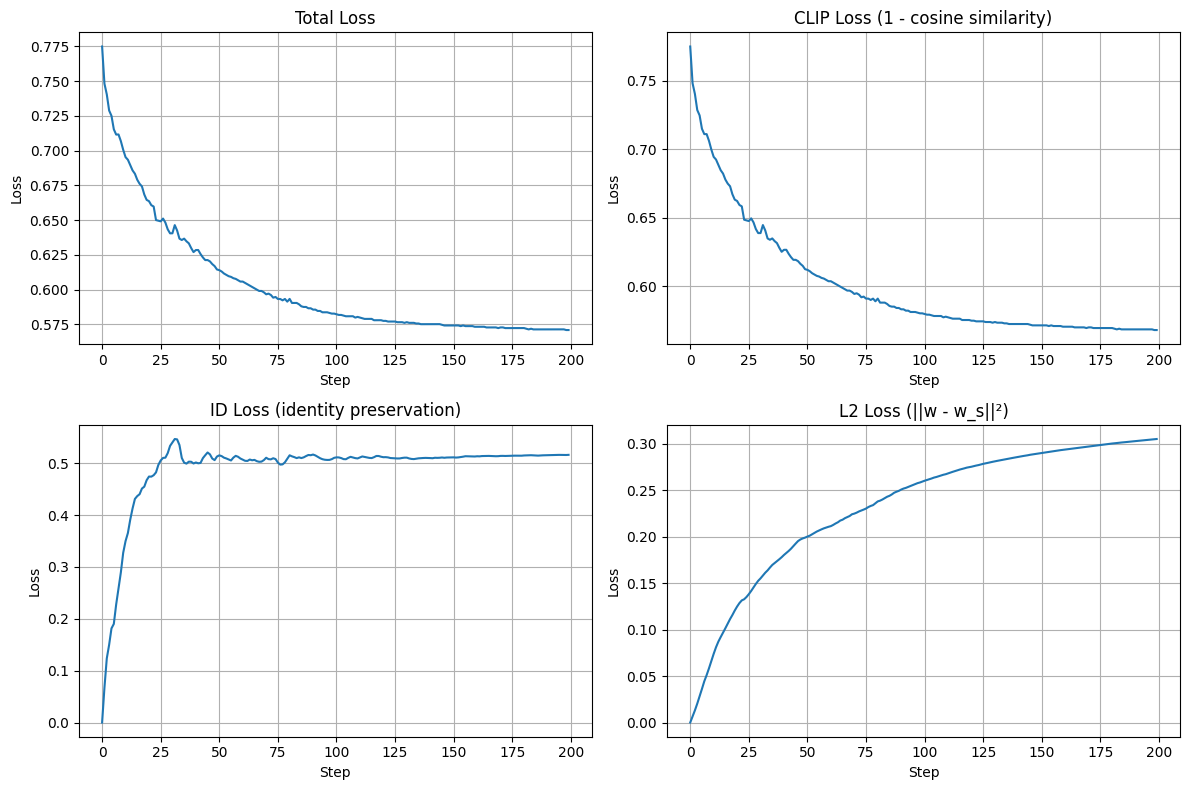


 Финальные значения потерь:
  Total Loss: 0.5708
  CLIP Loss:  0.5679
  ID Loss:    0.5161
  L2 Loss:    0.3050


In [57]:
# Визуализация всех лоссов
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Общий лосс
axes[0, 0].plot(losses['all'])
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True)

# CLIP Loss
axes[0, 1].plot(losses['clip'])
axes[0, 1].set_title('CLIP Loss (1 - cosine similarity)')
axes[0, 1].set_xlabel('Step')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True)

# ID Loss
axes[1, 0].plot(losses['id'])
axes[1, 0].set_title('ID Loss (identity preservation)')
axes[1, 0].set_xlabel('Step')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].grid(True)

# L2 Loss (регуляризация)
axes[1, 1].plot(losses['l2'])
axes[1, 1].set_title('L2 Loss (||w - w_s||²)')
axes[1, 1].set_xlabel('Step')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Вывод финальных значений
print(f"\n Финальные значения потерь:")
print(f"  Total Loss: {losses['all'][-1]:.4f}")
print(f"  CLIP Loss:  {losses['clip'][-1]:.4f}")
print(f"  ID Loss:    {losses['id'][-1]:.4f}")
print(f"  L2 Loss:    {losses['l2'][-1]:.4f}")

Сохряним результаты!

In [58]:
import os

filename = prompt

# Save the latents to a .pt file.
latent_path = os.path.join(save_dir, filename + ".pt")
torch.save(latent, latent_path)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
save_image(img_gen, image_path)


print(f"Ваше изображение и латенты успешно сохранены в папке {save_dir}")

Ваше изображение и латенты успешно сохранены в папке results


### Вывооды

Напишите ваши выводы, что получилось, что нет, почему получилось, почему нет.

Загрузка всех моделей

Реализация функций потерь

Генерация и визуализация


Не получилось корректно перекрасить волосы!!!!
Зацепился фон